1) Library import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

2) Obtaining Breast Cancer Wisconsin classification data set from https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'

features = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness',
            'concavity', 'concave_poinits', 'symmetry', 'fractal_dimension']
column_names = ['id', 'diagnosis']

for attr in ['mean', 'ste', 'largest']:
  for feature in features:
    column_names.append(feature + "_" + attr)

In [3]:
df = pd.read_csv(url, names=column_names)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_poinits_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_poinits_largest,symmetry_largest,fractal_dimension_largest
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         569 non-null    int64  
 1   diagnosis                  569 non-null    object 
 2   radius_mean                569 non-null    float64
 3   texture_mean               569 non-null    float64
 4   perimeter_mean             569 non-null    float64
 5   area_mean                  569 non-null    float64
 6   smoothness_mean            569 non-null    float64
 7   compactness_mean           569 non-null    float64
 8   concavity_mean             569 non-null    float64
 9   concave_poinits_mean       569 non-null    float64
 10  symmetry_mean              569 non-null    float64
 11  fractal_dimension_mean     569 non-null    float64
 12  radius_ste                 569 non-null    float64
 13  texture_ste                569 non-null    float64

In [5]:
# data summary
print ("Rows     : " ,df.shape[0])
print ("Columns  : " ,df.shape[1])
print ("\nFeatures : \n" ,df.columns.tolist())
print ("\nMissing values :  ", df.isnull().sum().values.sum())

Rows     :  569
Columns  :  32

Features : 
 ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_poinits_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_ste', 'texture_ste', 'perimeter_ste', 'area_ste', 'smoothness_ste', 'compactness_ste', 'concavity_ste', 'concave_poinits_ste', 'symmetry_ste', 'fractal_dimension_ste', 'radius_largest', 'texture_largest', 'perimeter_largest', 'area_largest', 'smoothness_largest', 'compactness_largest', 'concavity_largest', 'concave_poinits_largest', 'symmetry_largest', 'fractal_dimension_largest']

Missing values :   0


In [6]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [7]:
df = df.drop('id', axis=1)

In [8]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_poinits_mean,symmetry_mean,fractal_dimension_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_poinits_largest,symmetry_largest,fractal_dimension_largest
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
# Encoding target variable
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

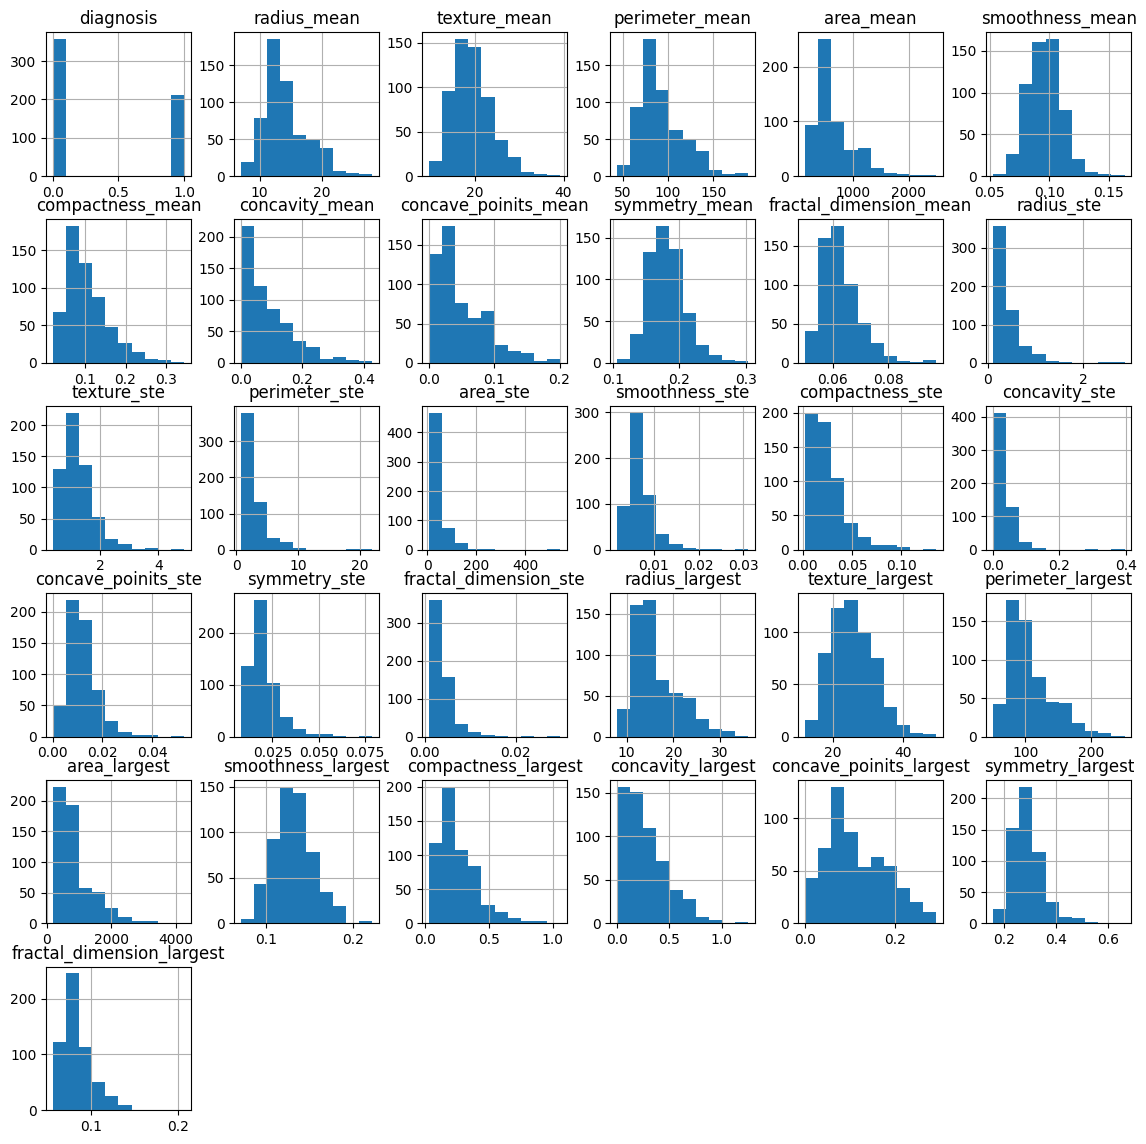

In [10]:
# Plotting the distribution of variables
df.hist(figsize=(14, 14))
plt.show()

In [11]:
# Split dataset into 80% training
train_dataset = df.sample(frac=0.80, random_state=1)

In [12]:
# Recover the remaining 20% for testing
test_dataset = df.drop(train_dataset.index)

In [13]:
# Create training and test datasets
X_train = train_dataset.drop("diagnosis", axis=1)
X_test = test_dataset.drop("diagnosis", axis=1)

y_train = train_dataset["diagnosis"]
y_test = test_dataset["diagnosis"]

In [14]:
# Normalize variables to the same value range
class Normalisation():
    def __init__(self, x):
        self.mean = np.mean(x, axis=0)
        self.std = np.std(x, axis = 0)

    def z_score(self, x):
        return (x - self.mean) / self.std

norm_X_train = Normalisation(X_train)
X_train = norm_X_train.z_score(X_train)
X_test = norm_X_train.z_score(X_test)

3. Logistic regression construction

In [15]:
class LogisticRegression():
    def __init__(self, learning_rate, n_epochs, threshold, log_every=20):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.threshold = threshold
        self.log_every = log_every
        self.loss_history = []
        self.weights = None
        self.bias = None
        

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        predictions = self.sigmoid(z)
        return predictions
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= self.threshold).astype(int)
    
    def log_loss(self, y_pred, y_test):
        eps = 1e-15
        y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
        log_loss = -np.mean(y_test * np.log(y_pred_clipped) + (1 - y_test) * np.log(1 - y_pred_clipped))
        return log_loss
    
    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.title("Evolution of Log_loss")
        plt.xlabel("Epochs")
        plt.ylabel("Log_loss")
        plt.show()

    
    def train(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

        for epochs in range(self.n_epochs):
            predictions = self.predict_proba(X)

            gradient_weights = np.dot(X.T, (predictions - y)) / n_samples
            gradient_bias = np.mean(predictions - y)

            self.weights -= gradient_weights * self.learning_rate
            self.bias -= gradient_bias * self.learning_rate

            loss_value = self.log_loss(predictions, y)
            self.loss_history.append(loss_value)

            if epochs % self.log_every == 0 or epochs == self.n_epochs - 1:
                print(f"Epoch {epochs+1}/{self.n_epochs} - Log_loss: {loss_value:.6f}")


Epoch 1/100 - Log_loss: 0.951126
Epoch 21/100 - Log_loss: 0.239417
Epoch 41/100 - Log_loss: 0.169633
Epoch 61/100 - Log_loss: 0.139209
Epoch 81/100 - Log_loss: 0.121223
Epoch 100/100 - Log_loss: 0.109545


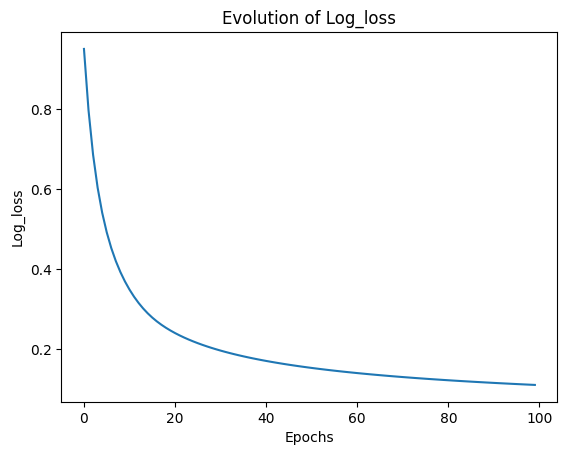

In [16]:
# Model training
model = LogisticRegression(learning_rate=0.1, n_epochs=100, threshold = 0.5)

model.train(X_train, y_train)
model.plot_loss()

In [17]:
# Making predictions on test dataset
y_pred = model.predict(X_test)

In [26]:
#  Model evaluation
class model_evaluation():
    def __init__(self, y_pred, y_test):

        self.y_pred = y_pred
        self.y_test = y_test

        self.TP = np.sum((y_test == 1) & (y_pred == 1))
        self.TN = np.sum((y_test == 0) & (y_pred == 0))
        self.FP = np.sum((y_test == 0) & (y_pred == 1))
        self.FN = np.sum((y_test == 1) & (y_pred == 0))

    def confusion_matrix(self):
        return np.array([[self.TP, self.FN], 
                        [self.FP, self.TN]])
    
    def accuracy(self):
        return (self.TP + self.TN) / len(self.y_pred)
    
    def precision(self):
        pos_precision = self.TP / (self.TP + self.FP)
        neg_precision = self.TN / (self.TN + self.FN)
        return pos_precision, neg_precision
    
    def recall(self):
        pos_recall = self.TP / (self.TP + self.FN)
        neg_recall = self.TN / (self.TN + self.FP)
        return pos_recall, neg_recall
    
    def f1_score(self):
        precision_pos, precision_neg = self.precision()
        recall_pos, recall_neg = self.recall()
        pos_f1 = 2 * (precision_pos * recall_pos) / (precision_pos + recall_pos)
        neg_f1 = 2 * (precision_neg * recall_neg) / (precision_neg + recall_neg)
        return pos_f1, neg_f1
    

In [27]:
evaluation = model_evaluation(y_pred, y_test)

print("Confusion matrix : ", evaluation.confusion_matrix())
print("Accuracy :", evaluation.accuracy())

precision_pos, precision_neg = evaluation.precision()
print("Precision 1 :", precision_pos)
print("Precision 0 :", precision_neg)

recall_pos, recall_neg = evaluation.recall()
print("Recall 1 :", recall_pos)
print("Recall 0 :", recall_neg)

f1_score_pos, f1_score_neg = evaluation.f1_score()
print("F1_score 1 :", f1_score_pos)
print("F1_score 0 :", f1_score_neg)

Matrice de confusion :  [[41  4]
 [ 0 69]]
Accuracy : 0.9649122807017544
Precision 1 : 1.0
Precision 0 : 0.9452054794520548
Recall 1 : 0.9111111111111111
Recall 0 : 1.0
F1_score 1 : 0.9534883720930233
F1_score 0 : 0.971830985915493


6. Implementation with Sklearn

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# Model instantiation
sk_model = LogisticRegression()
sk_model.fit(X_train, y_train)

# Prediction
y_pred_sklearn = sk_model.predict(X_test)

# Evaluation
print("Classification report :", classification_report(y_test, y_pred_sklearn))

Classification report :               precision    recall  f1-score   support

           0       0.95      1.00      0.97        69
           1       1.00      0.91      0.95        45

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

